# Building an End-to-End Image Classifier with CNNs.

### Mount Drive and Extract Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile
import os

zip_path = '/content/drive/MyDrive/AI_ML/FruitinAmazon.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

print("Dataset extracted successfully!")

Mounted at /content/drive
Dataset extracted successfully!


### Import All Libraries

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import tensorflow as tf

from PIL import Image, UnidentifiedImageError
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense,
    BatchNormalization, Dropout, Activation,
    GlobalAveragePooling2D
)
from tensorflow.keras.applications import VGG16
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import classification_report

print("All libraries imported successfully!")

All libraries imported successfully!


### Set Dataset Paths

In [ ]:
train_dir = '/content/dataset/FruitinAmazon/train'
test_dir  = '/content/dataset/FruitinAmazon/test'

## SECTION 2.1 — Data Understanding and Visualization

### Read Dataset Directory and Get Class Names

In [ ]:
class_names = sorted(os.listdir(train_dir))
print(f"Found {len(class_names)} classes: {class_names}")

Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


### Check for Corrupted Images

In [ ]:
corrupted_images = []  # Store paths of any bad images

# Loop through each class folder
for class_name in class_names:
  # Create a full path
    class_path = os.path.join(train_dir, class_name)
    # Check if the path actually exists and is a directory
    if os.path.isdir(class_path):
      # Iterate through every single filename
        for img_name in os.listdir(class_path):
          # Construct the full path to the specific image file
            img_path = os.path.join(class_path, img_name)
            try:
                with Image.open(img_path) as img:
                    img.verify()  # Check if image is valid
            except (IOError, UnidentifiedImageError, SyntaxError):
                corrupted_images.append(img_path)
                os.remove(img_path)  # Delete the corrupted image
                print(f"Removed corrupted image: {img_path}")

# Final result
if corrupted_images:
    print(f"\nTotal corrupted images removed: {len(corrupted_images)}")
else:
    print("\nNo corrupted images found.")


No corrupted images found.


Count Class Balance:

In [ ]:
class_counts = {}  # Dictionary to store counts per class

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        # Count only valid image files
        images = [img for img in os.listdir(class_path)
                  if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        class_counts[class_name] = len(images)

# Print class distribution in a table format
print("Class Distribution:")
print(f"{'Class Name':<25}{'Valid Image Count':>15}")
for class_name, count in class_counts.items():
    print(f"{class_name:<25}{count:>15}")

Class Distribution:
Class Name               Valid Image Count
acai                                  15
cupuacu                               15
graviola                              15
guarana                               15
pupunha                               15
tucuma                                15


## Visualize Random Images from Each Class

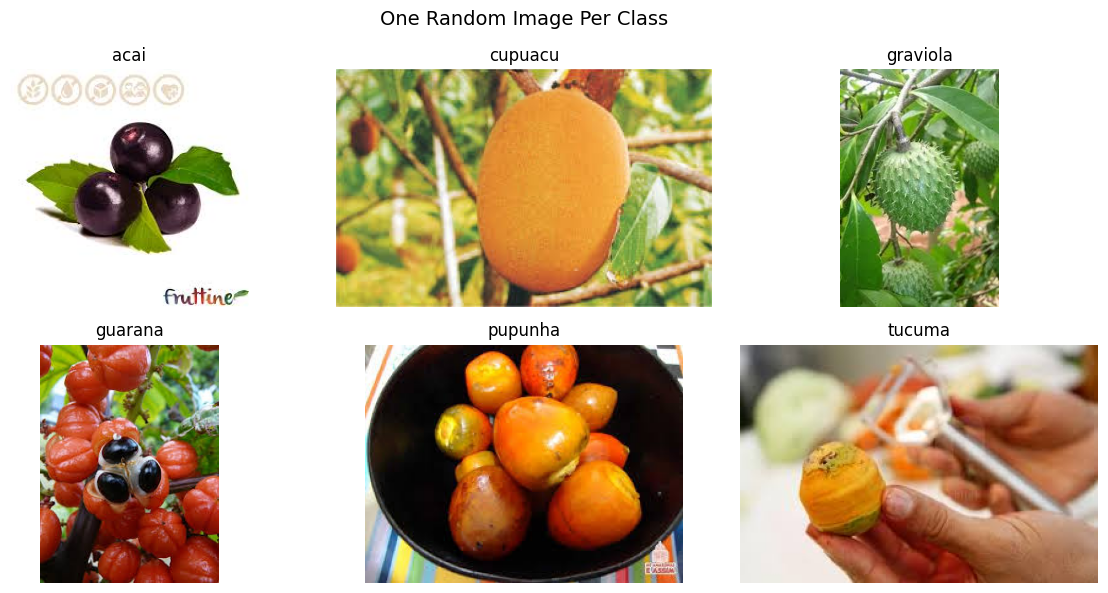

In [ ]:
selected_images = []   # Image file paths
selected_labels = []   # Corresponding class names

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path)
                  if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if images:
            selected_img = os.path.join(class_path, random.choice(images))
            selected_images.append(selected_img)
            selected_labels.append(class_name)

# Display in a 2-row grid
num_classes = len(selected_images)
cols = (num_classes + 1) // 2
rows = 2

fig, axes = plt.subplots(rows, cols, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    if i < num_classes:
        img = mpimg.imread(selected_images[i])
        ax.imshow(img)
        ax.set_title(selected_labels[i])
        ax.axis('off')
    else:
        ax.axis('off')  # Hide empty subplots

plt.suptitle("One Random Image Per Class", fontsize=14)
plt.tight_layout()

## SECTION 2.2 — Data Generation and Pre-processing

In [ ]:
# Image dimensions and batch size
img_height   = 224   # VGG16 expects 224x224 images
img_width    = 224
batch_size   = 16
num_classes  = len(class_names)  # = 6

print(f"Image size: {img_height}x{img_width}")
print(f"Batch size: {batch_size}")
print(f"Number of classes: {num_classes}")

Image size: 224x224
Batch size: 16
Number of classes: 6


In [ ]:
# Loading Training & Validation Data
# This creates two datasets: 80% for learning, 20% for tuning
train_ds, val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2, # Reserve 20% for validation
    subset='both',        # Returns both subsets at once
    seed=1337,            # Ensures the split is the same every time you run the code
    image_size=(img_height, img_width),
    batch_size=batch_size,
)

# --- Loading Test Data ---
test_ds = keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False  # Keeps order same for accurate final reporting
)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Using 18 files for validation.
Found 30 files belonging to 6 classes.


## Define Data Augmentation Layers (New Keras API)

In [ ]:
# Define augmentation layers
# RandomFlip: randomly mirrors the image left-right
# RandomRotation: randomly rotates image by up to 10% of 360 degrees
# RandomZoom: randomly zooms in or out slightly
# RandomContrast: randomly adjusts brightness/contrast

data_augmentation_layers = [
    layers.RandomFlip("horizontal"),       # Mirror image horizontally
    layers.RandomRotation(0.1),             # Rotate up to ~36 degrees
    layers.RandomZoom(0.1),                 # Zoom in/out by 10%
    layers.RandomContrast(0.1),             # Slight contrast change
]

def data_augmentation(images):
    """Apply all augmentation layers one by one."""
    for layer in data_augmentation_layers:
        images = layer(images)
    return images

print("Data augmentation layers defined!")

Data augmentation layers defined!


### Visualize What Data Augmentation Does

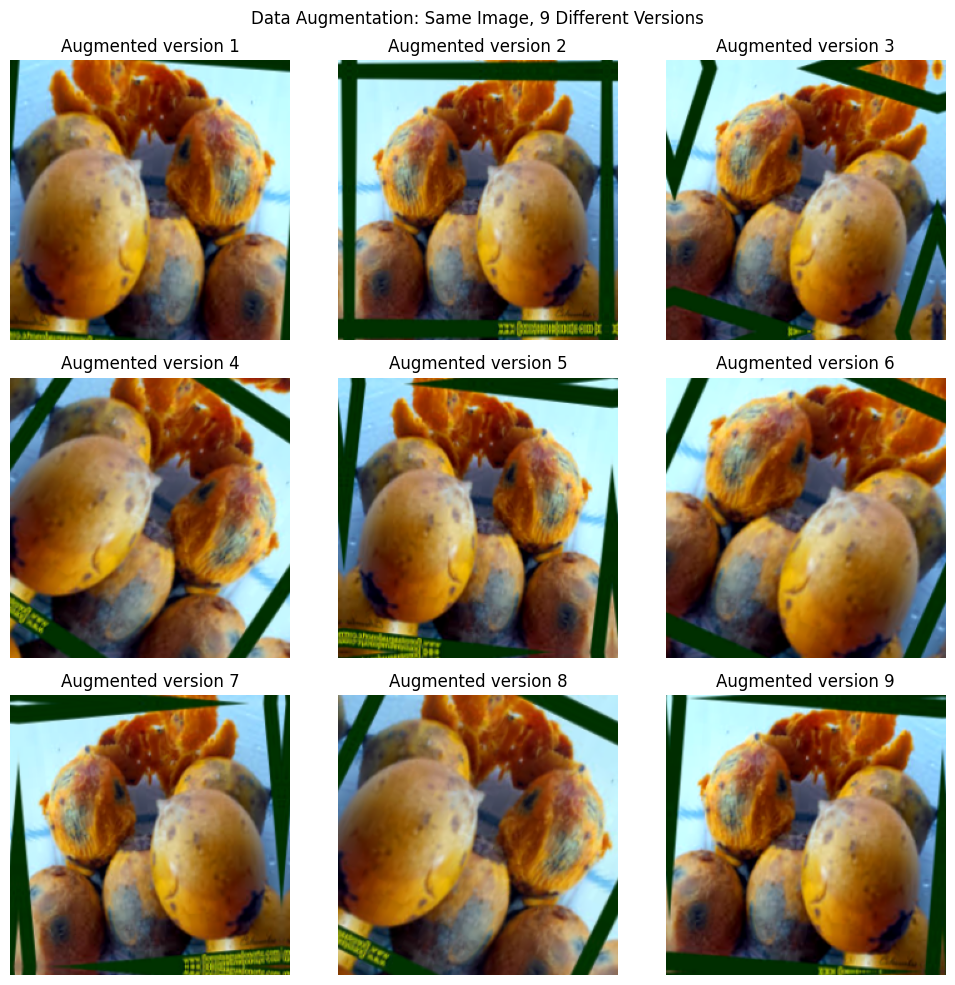

In [ ]:
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):  # Take one batch from training data
    for i in range(9):
        # Apply augmentation to the same first image 9 times
        augmented_images = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(augmented_images[0]).astype("uint8"))
        plt.title(f"Augmented version {i+1}")
        plt.axis("off")

plt.suptitle("Data Augmentation: Same Image, 9 Different Versions", fontsize=12)
plt.tight_layout()

## TASK 1 — Improved CNN with BatchNormalization and Dropout

In [ ]:
#Building the CNN model

model = keras.Sequential([

    # Define input size and channels (RGB = 3)
    layers.Input(shape=(img_height, img_width, 3)),

    # DATA AUGMENTATION (only active during training, off during evaluation)
    layers.Lambda(data_augmentation),

    # Normalize pixel values from 0-255 down to 0-1 for mathematical stability
    layers.Rescaling(1./255),

    # ── CONV BLOCK 1 ──
    # 32 filters, 3x3 kernel, same padding (output same size as input)
    Conv2D(32, (3, 3), padding='same', activation=None), # Search for 32 simple patterns
    BatchNormalization(),  # Normalise activations → faster, stable training
    Activation('relu'),    # Turns off negative signals (improves non-linearity)
    MaxPooling2D((2, 2)),  # Downsamples image to 112x112
    Dropout(0.25),         # Randomly deactivates 25% of connections to prevent "overfitting"

    # ── CONV BLOCK 2 ──
    # 64 filters — learns more complex patterns
    Conv2D(64, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # ── CONV BLOCK 3 ──
    # 128 filters — even more complex features
    Conv2D(128, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # ── CONV BLOCK 4 ──
    # 256 filters — highest level visual features
    Conv2D(256, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # --- CLASSIFIER HEAD ---
    Flatten(), # Converts the final 14x14x256 maps into a 1D vector of 50,176 values

    # ── FULLY CONNECTED LAYER 1 ──
    Dense(512, activation=None), # Large "Thinking" layer
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5), # Heavier dropout for the dense layers

    # ── FULLY CONNECTED LAYER 2 ──
    Dense(256, activation=None), # Refines the features further
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    # ── OUTPUT LAYER ──
    Dense(num_classes, activation='softmax')
])

# Print the model architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             

 Total params: 26,216,902 (100.01 MB)

 Trainable params: 26,214,406 (100.00 MB)

 Non-trainable params: 2,496 (9.75 KB)

### Compile and Train the Improved CNN

In [ ]:
# ── Compile the model ──
model.compile(
    optimizer='adam',                        # Adam auto-adjusts learning rate
    loss='sparse_categorical_crossentropy',  # Measuring error for integer labels
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


In [ ]:
# Automation Tools
# ModelCheckpoint: saves the model whenever validation accuracy improves
checkpoint_cb = ModelCheckpoint(
    'best_model_ws6.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# EarlyStopping: stops training early if no improvement for 20 epochs
# This saves time and prevents overfitting
earlystop_cb = EarlyStopping(
    monitor='val_accuracy',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

print("Callbacks ready!")

Callbacks ready!


###Train the model

In [ ]:
history = model.fit(
    train_ds,
    epochs=250,
    validation_data=val_ds,
    callbacks=[checkpoint_cb, earlystop_cb]
)

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.2056 - loss: 2.5388
Epoch 1: val_accuracy improved from None to 0.33333, saving model to best_model_ws6.keras

Epoch 1: finished saving model to best_model_ws6.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 37s 6s/step - accuracy: 0.2361 - loss: 2.3308 - val_accuracy: 0.3333 - val_loss: 1.7518
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.3042 - loss: 1.7620
Epoch 2: val_accuracy did not improve from 0.33333
5/5 ━━━━━━━━━━━━━━━━━━━━ 24s 5s/step - accuracy: 0.2917 - loss: 1.8125 - val_accuracy: 0.0556 - val_loss: 1.8493
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4375 - loss: 1.4747
Epoch 3: val_accuracy did not improve from 0.33333
5/5 ━━━━━━━━━━━━━━━━━━━━ 39s 4s/step - accuracy: 0.4167 - loss: 1.5101 - val_accuracy: 0.0556 - val_loss: 2.0706
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5233 - loss: 1.3467
Epoch 4: val_accuracy did not improve from 0.33333
5/5 ━━━━━━━━━━━━━━━━━━━━ 40s 4s/st

### Plot Training History

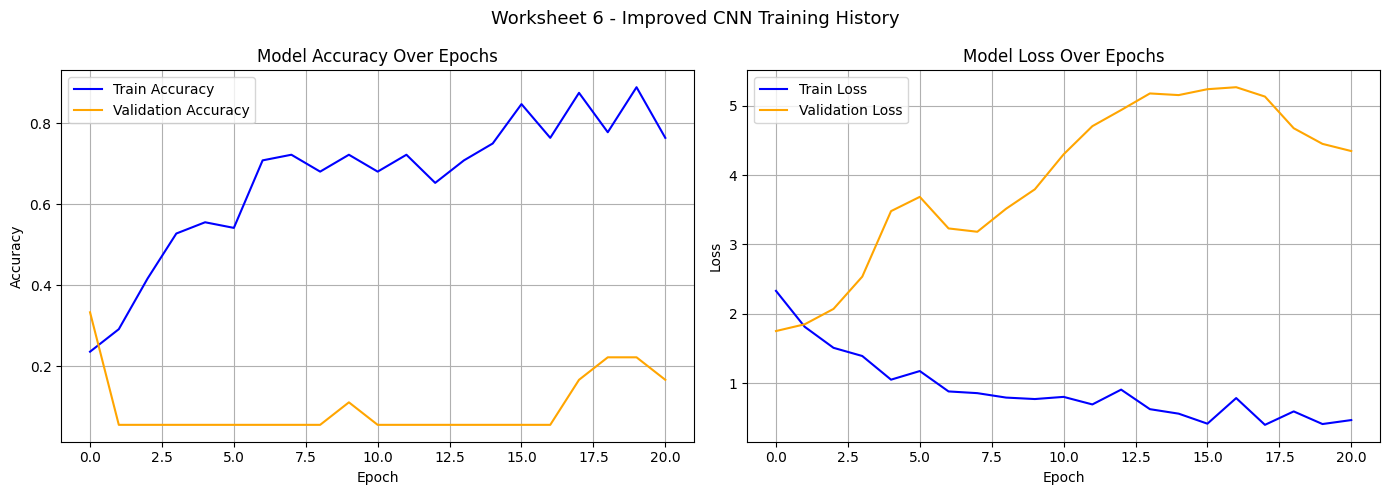

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Accuracy Plot ──
axes[0].plot(history.history['accuracy'],     label='Train Accuracy',      color='blue')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
axes[0].set_title('Model Accuracy Over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# ── Loss Plot ──
axes[1].plot(history.history['loss'],     label='Train Loss',      color='blue')
axes[1].plot(history.history['val_loss'], label='Validation Loss', color='orange')
axes[1].set_title('Model Loss Over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Worksheet 6 - Improved CNN Training History', fontsize=13)
plt.tight_layout()
plt.show()

### Evaluate and Classification Report — Improved CNN

In [ ]:
# Evaluate on test set
print("=" * 40)
print("Improved CNN - Test Set Evaluation")
print("=" * 40)
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test Loss     : {test_loss:.4f}")

Improved CNN - Test Set Evaluation
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 595ms/step - accuracy: 0.3667 - loss: 1.7177
Test Accuracy : 0.3667
Test Loss     : 1.7177


In [ ]:
# Get true labels and predictions from test set
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)
    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Print classification report
print("\nClassification Report — Improved CNN:")
print(classification_report(y_true, y_pred, target_names=class_names))


Classification Report — Improved CNN:
              precision    recall  f1-score   support

        acai       0.25      0.40      0.31         5
     cupuacu       0.33      0.20      0.25         5
    graviola       0.27      0.60      0.38         5
     guarana       0.00      0.00      0.00         5
     pupunha       0.62      1.00      0.77         5
      tucuma       0.00      0.00      0.00         5

    accuracy                           0.37        30
   macro avg       0.25      0.37      0.28        30
weighted avg       0.25      0.37      0.28        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# TASK 2 — Transfer Learning with VGG16

In [ ]:
# Load VGG16 pre-trained on ImageNet
# include_top=False → remove the final 3 dense layers
# input_shape=(224,224,3) → VGG16 expects this size

base_model = VGG16(
    weights='imagenet',       # Use weights learned from 1.2M images
    include_top=False,        # Don't include the final classification layers
    input_shape=(224, 224, 3) # Our image size
)

print(f"VGG16 loaded successfully!")
print(f"Number of layers in VGG16: {len(base_model.layers)}")
base_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
VGG16 loaded successfully!
Number of layers in VGG16: 19


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

### Freeze All VGG16 Layers

In [ ]:
# Freeze ALL layers of the base model
for layer in base_model.layers: # loop through all 19 VGG16 layers
    layer.trainable = False # lock each one — no updates allowed

# Confirm: count how many layers are trainable vs frozen
trainable_count = sum(1 for layer in base_model.layers if layer.trainable)
frozen_count    = sum(1 for layer in base_model.layers if not layer.trainable)

print(f"Trainable layers : {trainable_count}")
print(f"Frozen layers    : {frozen_count}")
print("\nAll VGG16 layers are frozen — their knowledge is preserved!")

Trainable layers : 0
Frozen layers    : 19

All VGG16 layers are frozen — their knowledge is preserved!


### Add Custom Output Layers on Top of VGG16

In [ ]:
# Start from VGG16's output
# base_model.output is the last layer of VGG16 after block5_pool
# shape: (None, 7, 7, 512)
# VGG16 has already extracted deep visual features from the image
# We just need to classify those features for our 6 fruits

x = base_model.output
# x is now a tensor representing (None, 7, 7, 512)
# 7x7 spatial grid, 512 feature maps at each position


# GlobalAveragePooling2D:
# Converts the 3D feature maps (7x7x512) into a 1D vector (512,)
# Less parameters than Flatten → reduces overfitting risk
x = GlobalAveragePooling2D()(x)

# Fully connected layer with 1024 neurons
x = Dense(1024, activation='relu')(x)

# Dropout for regularisation
x = Dropout(0.5)(x)

# Another fully connected layer
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)

# OUTPUT LAYER: One neuron per class, softmax for probabilities
output = Dense(num_classes, activation='softmax')(x)

print("Custom layers added on top of VGG16!")

Custom layers added on top of VGG16!


### Build the Final Transfer Learning Model

In [ ]:
# Combine VGG16 base + our custom top layers into one model
transfer_model = Model(
    inputs=base_model.input,  # Input: same as VGG16 input
    outputs=output            # Output: our custom classification output
)

# Print summary — you'll see VGG16 layers + our new layers
transfer_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 15,503,942 (59.14 MB)

 Trainable params: 789,254 (3.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

### Prepare Datasets for VGG16

In [ ]:
from tensorflow.keras.applications.vgg16 import preprocess_input

# Apply VGG16 preprocessing to all datasets
# preprocess_input subtracts ImageNet mean values from RGB channels
train_ds_vgg = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds_vgg   = val_ds.map(lambda x, y: (preprocess_input(x), y))
test_ds_vgg  = test_ds.map(lambda x, y: (preprocess_input(x), y))

print("Datasets preprocessed for VGG16!")

Datasets preprocessed for VGG16!


### Compile and Train the Transfer Learning Model

In [ ]:
# Compile the transfer learning model
# Use a smaller learning rate (0.0001) for fine-tuning — don't disturb the frozen layers too much
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Transfer learning model compiled!")

Transfer learning model compiled!


In [ ]:
# Callbacks for transfer learning model
tl_checkpoint_cb = ModelCheckpoint(
    'best_transfer_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

tl_earlystop_cb = EarlyStopping(
    monitor='val_accuracy',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

print("Callbacks ready!")

Callbacks ready!


In [ ]:
# Train the transfer learning model
# Only the top custom layers will be trained (VGG16 is frozen)
tl_history = transfer_model.fit(
    train_ds_vgg,
    epochs=100,
    validation_data=val_ds_vgg,
    callbacks=[tl_checkpoint_cb, tl_earlystop_cb]
)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.2243 - loss: 9.3543 
Epoch 1: val_accuracy improved from None to 0.27778, saving model to best_transfer_model.keras

Epoch 1: finished saving model to best_transfer_model.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 88s 18s/step - accuracy: 0.1944 - loss: 9.6521 - val_accuracy: 0.2778 - val_loss: 4.0112
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.2677 - loss: 6.8950  
Epoch 2: val_accuracy improved from 0.27778 to 0.33333, saving model to best_transfer_model.keras

Epoch 2: finished saving model to best_transfer_model.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 67s 14s/step - accuracy: 0.2917 - loss: 6.4174 - val_accuracy: 0.3333 - val_loss: 2.4942
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.3889 - loss: 4.4424  
Epoch 3: val_accuracy improved from 0.33333 to 0.38889, saving model to best_transfer_model.keras

Epoch 3: finished saving model to best_transfer_model.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 59s 12s/step - accura

### Plot Transfer Learning Training History

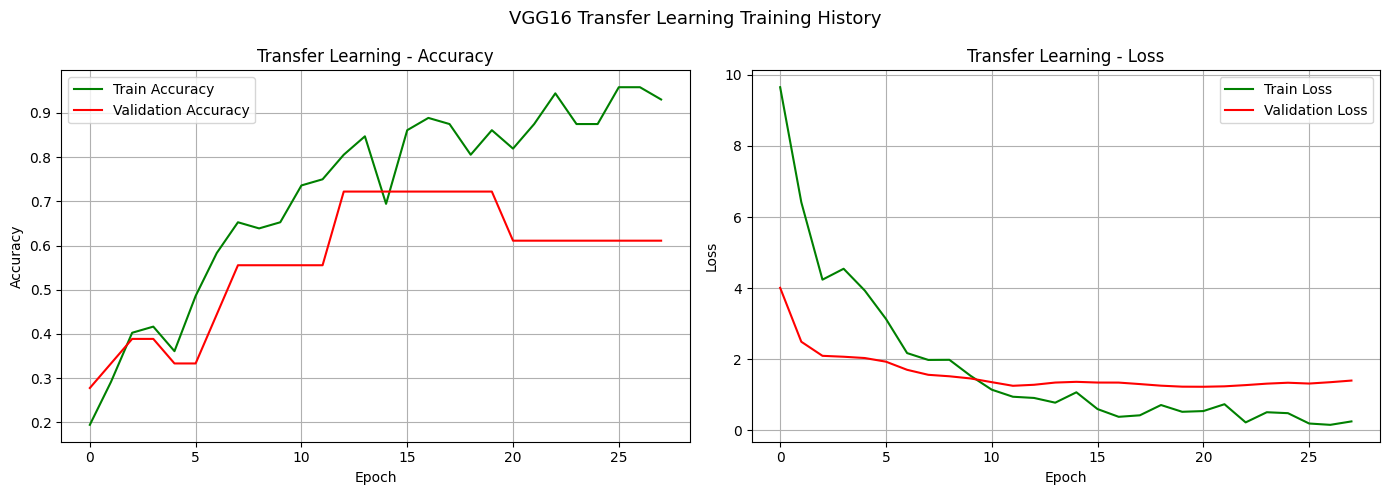

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(tl_history.history['accuracy'],     label='Train Accuracy',      color='green')
axes[0].plot(tl_history.history['val_accuracy'], label='Validation Accuracy', color='red')
axes[0].set_title('Transfer Learning - Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(tl_history.history['loss'],     label='Train Loss',      color='green')
axes[1].plot(tl_history.history['val_loss'], label='Validation Loss', color='red')
axes[1].set_title('Transfer Learning - Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('VGG16 Transfer Learning Training History', fontsize=13)
plt.tight_layout()
plt.show()

### Evaluate Transfer Learning Model

In [ ]:
print("VGG16 Transfer Learning - Test Evaluation")
tl_loss, tl_acc = transfer_model.evaluate(test_ds_vgg)
print(f"Test Accuracy : {tl_acc:.4f}")
print(f"Test Loss     : {tl_loss:.4f}")

VGG16 Transfer Learning - Test Evaluation
2/2 ━━━━━━━━━━━━━━━━━━━━ 19s 9s/step - accuracy: 0.8000 - loss: 1.1477
Test Accuracy : 0.8000
Test Loss     : 1.1477


### Classification Report — Transfer Learning Model

In [ ]:
# Get predictions from transfer learning model
y_true_tl = []
y_pred_tl = []

for images, labels in test_ds_vgg:
    preds = transfer_model.predict(images, verbose=0)
    pred_labels = np.argmax(preds, axis=1)
    y_true_tl.extend(labels.numpy())
    y_pred_tl.extend(pred_labels)

y_true_tl = np.array(y_true_tl)
y_pred_tl = np.array(y_pred_tl)

print("Classification Report — VGG16 Transfer Learning:")
print(classification_report(y_true_tl, y_pred_tl, target_names=class_names))

Classification Report — VGG16 Transfer Learning:
              precision    recall  f1-score   support

        acai       0.71      1.00      0.83         5
     cupuacu       1.00      0.80      0.89         5
    graviola       1.00      1.00      1.00         5
     guarana       1.00      1.00      1.00         5
     pupunha       1.00      0.40      0.57         5
      tucuma       0.43      0.60      0.50         5

    accuracy                           0.80        30
   macro avg       0.86      0.80      0.80        30
weighted avg       0.86      0.80      0.80        30




# Final Comparison: Scratch CNN vs Transfer Learning

Strategy                              Test Accuracy
Training from Scratch                         36.7%
VGG16 Transfer Learning                       80.0%


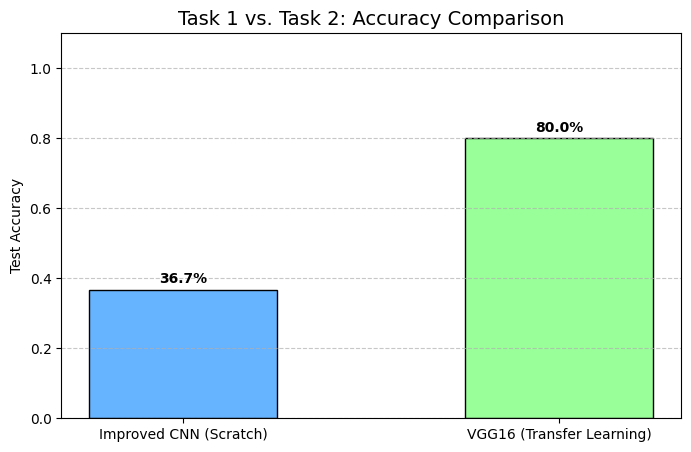

In [ ]:
import matplotlib.pyplot as plt

# Comparison Data from your Worksheet 6 results
models_ws6 = ['Improved CNN (Scratch)', 'VGG16 (Transfer Learning)']
# These variables should contain your model.evaluate results
accuracies_ws6 = [test_acc, tl_acc]
colors = ['#66b3ff', '#99ff99'] # Blue and Green

# 1. Print the Comparison Table
print(f"{'Strategy':<30} {'Test Accuracy':>20}")
print(f"{'Training from Scratch':<30} {f'{test_acc*100:.1f}%':>20}")
print(f"{'VGG16 Transfer Learning':<30} {f'{tl_acc*100:.1f}%':>20}")


# 2. Generate the Comparison Bar Chart
plt.figure(figsize=(8, 5))
bars = plt.bar(models_ws6, accuracies_ws6, color=colors, edgecolor='black', width=0.5)

# Add percentage labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval*100:.1f}%',
             ha='center', va='bottom', fontweight='bold')

plt.title('Task 1 vs. Task 2: Accuracy Comparison', fontsize=14)
plt.ylabel('Test Accuracy')
plt.ylim(0, 1.1) # Scale to 100%
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()